In [1]:
import pandas as pd
import seaborn as sb
import pingouin as pg
import numpy as np
import statsmodels.formula.api as smf

from matplotlib import rcParams
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/behavior'])
import matplotlib.pyplot as plt
plt.style.use(['/Users/amonast/Documents/GitHub/Amy_Reviews/paper_style.mplstyle'])

In [2]:
from running import percent_run_all
base_dir='/Volumes/AM_SSD1/Spont2P'
file_key='/Volumes/AM_SSD1/Spont2P/Data_info.csv'
metadata_path = '/Volumes/AM_SSD1/Spont2P/xml_metadata'
wheel_path = '/Volumes/AM_SSD1/Spont2P/Behavior/Wheel_csvs'
info = pd.read_csv(file_key)
path= '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure3-Supp4'

In [3]:
animals= ['989N',
    '994R',
    '9972R',
    '217R',
    '217N',
    '218L',
    '034R',
    '149L',
    '146R',
    '160R',
    '493R',
    '492N',
    '1912L']

fov_lists=[['FOV1','FOV2'],
    ['FOV1','FOV2'],
    ['FOV1','FOV2'],
    ['FOV1'],
    ['FOV1','FOV2'],
    ['FOV1','FOV2'],
    ['FOV1'],
    ['FOV1','FOV2'],
    ['FOV2'],
    ['FOV1','FOV2'],
    ['FOV1'],
    ['FOV1','FOV2'],
    ['FOV1','FOV2']]

sessions = ['Baseline','Post']
df = percent_run_all(animals,fov_lists,sessions,file_key,base_dir)
df['session']=df.Session.map({'Baseline':'D0','Post':'D4'})

### Animals Percent Time Running - SuppFig4A

In [4]:
df3 = df.groupby(['Animal','Session','Group','session']).mean(['% Run']).reset_index()
df1 = df3.loc[df3.Session=='Baseline'].reset_index(drop=True)
df2 = df3.loc[df3.Session=='Post'].reset_index(drop=True)
df_ = pd.concat([df1,df2],ignore_index=False).reset_index()

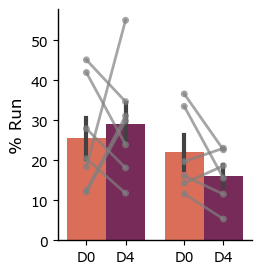

In [5]:
fig,ax=plt.subplots(figsize=(2.5,3))
sb.barplot(data=df_,x='Group',y='% Run',order = ['FC','HC'],hue='session',errorbar='se',palette='rocket_r',ax=ax)
sb.stripplot(data=df_,x='Group',y='% Run',order = ['FC','HC'],hue='session',dodge=True,jitter=False,palette=['gray','gray'],legend=False,ax=ax,alpha=0.7)

x1,x2,x3,x4 = -.2,.2,.8,1.2
for ani in np.unique(df_['Animal'].values):
    pre = df_['% Run'].loc[(df_['Animal']==ani)&(df_['Session']=='Baseline')].values[0]
    post = df_['% Run'].loc[(df_['Animal']==ani)&(df_['Session']=='Post')].values[0]
    if df_.Group.loc[df_.Animal==ani].values[0]=='HC':
        plt.plot([x3,x4],[pre,post],color='gray',alpha=.7)
    else:
        plt.plot([x1,x2],[pre,post],color='gray',alpha=.7)
sb.despine()
plt.xticks([x1,x2,x3,x4] ,labels=['D0','D4','D0','D4'])
plt.legend().remove()
plt.xlabel('')
plt.savefig(f'{path}/percent_time_run_mice.svg',transparent=True)



In [6]:
pg.mixed_anova(data=df_,dv='% Run',between='Group',within='Session',subject='index')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,445.283839,1,11,445.283839,3.111901,0.105437,0.220516,NaN
1,Session,3.116250,1,11,3.116250,0.023478,0.880996,0.002130,1.0
2,Interaction,148.408057,1,11,148.408057,1.118106,0.312996,0.092267,NaN


In [7]:
pg.pairwise_tests(data=df_,dv='% Run',between='Group',within='Session',subject='index',padjust='fdr_bh',within_first=False)

,Contrast,Group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Group,-,FC,HC,False,True,1.789035,10.999987,two-sided,0.101148,NaN,NaN,1.18,0.912959
1,Session,-,Baseline,Post,True,True,0.152476,12.000000,two-sided,0.881345,NaN,NaN,0.281,0.054540
2,Group * Session,FC,Baseline,Post,True,True,-0.482048,6.000000,two-sided,0.646851,0.646851,fdr_bh,0.389,-0.255349
3,Group * Session,HC,Baseline,Post,True,True,1.596148,5.000000,two-sided,0.171343,0.342687,fdr_bh,0.877,0.608592


### FOVs

In [8]:
pre = df.loc[df.Session=='Baseline'].reset_index(drop=True).reset_index()
post = df.loc[df.Session=='Post'].reset_index(drop=True).reset_index()
dfs = pd.concat([pre,post],ignore_index=False)
dfs.to_csv('percent_run-rest.csv')

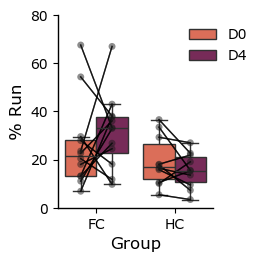

In [9]:

fig,ax=plt.subplots(figsize=(2,2.5))
sb.boxplot(data=df,x='Group',y='% Run',hue='session',palette='rocket_r',ax=ax,showfliers=False)#errwidth=1.5,capsize=.1,errorbar='se')
sb.stripplot(data=df,x='Group',y='% Run',hue='session',dodge=True,jitter=False,palette=['.1','.1'],legend=False,ax=ax,alpha=0.5)

x1,x2,x3,x4 = -.2,.2,.8,1.2
for ani in np.unique(df['Animal'].values):
    fovs = df['FOV'].loc[df['Animal']==ani].values
    for fov in fovs:
        if  df.Group.loc[df.Animal==ani].values[0]=='HC':
            pre_hc = df['% Run'].loc[(df['Animal']==ani)&(df['Session']=='Baseline')&(df['FOV']==fov)].values[0]
            post_hc = df['% Run'].loc[(df['Animal']==ani)&(df['Session']=='Post')&(df['FOV']==fov)].values[0]
            plt.plot([x3,x4],[pre_hc,post_hc],color='k',alpha=0.7,lw=1)

        elif  df.Group.loc[df.Animal==ani].values[0]=='FC':
            pre_fc = df['% Run'].loc[(df['Animal']==ani)&(df['Session']=='Baseline')&(df['FOV']==fov)].values[0]
            post_fc = df['% Run'].loc[(df['Animal']==ani)&(df['Session']=='Post')&(df['FOV']==fov)].values[0]
            plt.plot([x1,x2],[pre_fc,post_fc],color='k',alpha=0.7,lw=1)
sb.despine()
#plt.xticks([x1,x2,x3,x4] ,labels=['D0','D4','D0','D4'])
plt.xticks([0,1] ,labels=['FC','HC'])

plt.ylim([0,80])
# plt.hlines(75,0,1,color='k',linewidth=1)
# plt.text(.5,75,'*',ha='center')
plt.legend(frameon=False,bbox_to_anchor=(1.3,1))
plt.savefig(f'{path}/percent_time_run_fovs.svg',transparent=True)

In [10]:
pg.normality(dfs, dv='% Run',group='Group')

,W,pval,normal
Group,,,
FC,0.909364,0.034168,False
HC,0.961136,0.566790,True


In [11]:
pg.mixed_anova(data=dfs,dv='% Run',within='Session',between='Group',subject='index')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,1370.147444,1,20,1370.147444,6.468968,0.019348,0.244398,NaN
1,Session,23.828736,1,20,23.828736,0.138710,0.713484,0.006888,1.0
2,Interaction,257.619766,1,20,257.619766,1.499639,0.234956,0.069752,NaN


In [12]:
pg.pairwise_tests(data=dfs,dv='% Run',within='Session',between='Group',subject='index',padjust='holm',within_first=False,parametric=False)

,Contrast,Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,93.0,NaN,two-sided,0.032114,NaN,NaN,1.047671
1,Session,-,Baseline,Post,True,False,NaN,124.0,two-sided,0.949270,NaN,NaN,-0.097135
2,Group * Session,FC,Baseline,Post,True,False,NaN,29.0,two-sided,0.469727,0.550781,holm,-0.338760
3,Group * Session,HC,Baseline,Post,True,False,NaN,16.0,two-sided,0.275391,0.550781,holm,0.405479


In [13]:
# Rename column to make formula syntax easier
dfs = dfs.rename(columns={'% Run': 'percentRun'})

# Convert to categorical if not already
dfs['Group'] = dfs['Group'].astype('category')
dfs['State'] = dfs['Session'].astype('category')
dfs['Animal_FOV'] =  dfs['Animal'] + dfs['FOV']
# Fit linear mixed-effects model
model = smf.mixedlm("percentRun ~ Group * Session", dfs, groups=dfs["Animal_FOV"],re_formula="~Session")
result = model.fit()
# View summary
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      percentRun
No. Observations:       44           Method:                  REML      
No. Groups:             22           Scale:                   124.3179  
Min. group size:        2            Log-Likelihood:          -166.1942 
Max. group size:        2            Converged:               Yes       
Mean group size:        2.0                                             
------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------
Intercept                    25.693    4.360  5.892 0.000  17.147 34.239
Group[T.HC]                  -6.347    6.468 -0.981 0.326 -19.024  6.329
Session[T.Post]               5.890    5.351  1.101 0.271  -4.598 16.377
Group[T.HC]:Session[T.Post]  -9.719    7.937 -1.225 0.221 -25.274  5.

# Locmotion --> Rates ;


In [16]:
df1 = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_rest_weighted_5std_all.csv')#'/Volumes/AM_SSD1/Spont2P/Analysis/rates/rates_rest_mice_df_weighted_5std.csv')
df1['Population']=df1['Population'].replace({True:'Tagged',False:'Non-Tagged'})
df_reg = df1.loc[(df1['Baseline']!=-1)&(df1['Post']!=-1)]
df_reg = df_reg.drop('Unnamed: 0',axis=1)

means1 = pd.DataFrame()
for session in ['Baseline','Post']:
    dfs = df_reg.loc[df_reg['Session']==session]
    for group in ['FC','HC']:
        dfg = dfs.loc[dfs['Group']==group]
        for ani in np.unique(dfg['Animal']):
            dfa = dfg.loc[dfg['Animal']==ani]
            mean_ = dfa['Event Rate'].loc[dfa['Population']=='Tagged'].mean()
            means1 = pd.concat([means1,pd.DataFrame({'Animal':[ani],'Group':[group],'Session':[session],
                                                    'Mean Event Rate (Hz)':[mean_]})],ignore_index=True)
df_pre = means1.loc[means1['Session']=='Baseline'].reset_index()
df_post = means1.loc[means1['Session']=='Post'].reset_index()
means = pd.concat([df_pre,df_post],ignore_index=False)
means = means.drop('index',axis=1)
means_rest = means.reset_index()
means_rest['State']=['Rest']*len(means_rest)

df1 = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_run_weighted_5std_all.csv')
df1['Population']=df1['Population'].replace({True:'Tagged',False:'Non-Tagged'})
df_reg = df1.loc[(df1['Baseline']!=-1)&(df1['Post']!=-1)]
df_reg = df_reg.drop('Unnamed: 0',axis=1)

means1 = pd.DataFrame()
for session in ['Baseline','Post']:
    dfs = df_reg.loc[df_reg['Session']==session]
    for group in ['FC','HC']:
        dfg = dfs.loc[dfs['Group']==group]
        for ani in np.unique(dfg['Animal']):
            dfa = dfg.loc[dfg['Animal']==ani]
            mean_ = dfa['Event Rate'].loc[dfa['Population']=='Tagged'].mean()
            means1 = pd.concat([means1,pd.DataFrame({'Animal':[ani],'Group':[group],'Session':[session],
                                                    'Mean Event Rate (Hz)':[mean_]})],ignore_index=True)
            
df_pre = means1.loc[means1['Session']=='Baseline'].reset_index()
df_post = means1.loc[means1['Session']=='Post'].reset_index()
means = pd.concat([df_pre,df_post],ignore_index=False)
means = means.drop('index',axis=1)
means_run = means.reset_index()
means_run['State']=['Run']*len(means_run)

In [17]:
all_df = pd.concat([means_rest, means_run])

# Supp Fig 4I - D0

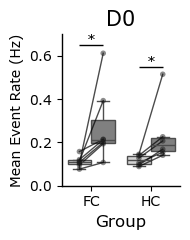

In [18]:
fig,ax=plt.subplots(figsize=(2,2.5))
pre = all_df.loc[all_df.Session=='Baseline']

# sb.barplot(data=pre,hue='State',y='Mean Event Rate (Hz)',x='Group',
#            order=['FC','HC'],dodge=True,errorbar='se',ax=ax,palette=['lightgray','gray'],
#            errwidth=1.5,capsize=.1)
sb.boxplot(data=pre,hue='State',y='Mean Event Rate (Hz)',x='Group',showfliers=False,dodge=True,ax=ax,palette=['lightgray','gray'])
sb.stripplot(data=pre,hue='State',y='Mean Event Rate (Hz)',order=['FC','HC'],dodge=True,x='Group',palette=['.1','.1'],size=4,jitter=False,alpha=.5,ax=ax)
x1,x2,x3,x4 = -.2,.2,.8,1.2
for ani in np.unique(pre['Animal'].values):
    rest = pre['Mean Event Rate (Hz)'].loc[(pre['Animal']==ani)&(pre['State']=='Rest')].values[0]
    run = pre['Mean Event Rate (Hz)'].loc[(pre['Animal']==ani)&(pre['State']=='Run')].values[0]
    if pre.Group.loc[pre.Animal==ani].values[0]=='HC':
        plt.plot([x3,x4],[rest,run],color='k',alpha=.7,lw=1)
    else:
        plt.plot([x1,x2],[rest,run],color='k',alpha=.7,lw=1)
ax.get_legend().set_visible(False)

# Order of boxes: [FC-Rest, FC-Run, HC-Rest, HC-Run]
box_colors = ['#a4d7ef', '#27aae1', '#d4b69b', '#a97c50']  # FC-rest, FC-run, HC-rest, HC-run

for i, patch in enumerate(ax.artists):  # ax.artists contains the boxes
    patch.set_facecolor(box_colors[i])
    patch.set_edgecolor('k')
    patch.set_linewidth(1)

plt.xlabel('Group')
plt.ylabel('Mean Event Rate (Hz)',fontdict={'size':10})
plt.ylim([0,.7])
plt.title('D0')
sb.despine()
plt.hlines(.65,-.2,.2,color='k',linewidth=1)
plt.text(0,.65,'*',ha='center')
plt.hlines(.55,.8,1.2,color='k',linewidth=1)
plt.text(1,.55,'*',ha='center')
plt.tight_layout()
plt.savefig(f'{path}/rest&run_meanani_allcells_pre.svg',transparent=True)

## Supp 4I Stats

In [19]:
pg.normality(pre,dv='Mean Event Rate (Hz)',group='State')

,W,pval,normal
State,,,
Rest,0.969718,0.890893,True
Run,0.773049,0.003319,False


In [20]:
pg.homoscedasticity(pre,dv='Mean Event Rate (Hz)',group='Group')

,W,pval,equal_var
levene,0.441908,0.51254,True


In [21]:
pg.mixed_anova(data=pre,dv='Mean Event Rate (Hz)',between='Group',within='State',subject='index',)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.001913,1,11,0.001913,0.136235,0.719060,0.012233,NaN
1,State,0.134591,1,11,0.134591,11.692976,0.005728,0.515269,1.0
2,Interaction,0.003604,1,11,0.003604,0.313137,0.586975,0.027679,NaN


In [22]:
pg.pairwise_tests(data=pre,dv='Mean Event Rate (Hz)',between='Group',within='State',subject='index',padjust='holm',parametric=False,within_first=False)

,Contrast,Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,25.0,NaN,two-sided,0.628205,NaN,NaN,0.191022
1,State,-,Rest,Run,True,False,NaN,0.0,two-sided,0.000244,NaN,NaN,-1.275154
2,Group * State,FC,Rest,Run,True,False,NaN,0.0,two-sided,0.015625,0.03125,holm,-1.269035
3,Group * State,HC,Rest,Run,True,False,NaN,0.0,two-sided,0.031250,0.03125,holm,-1.083732


In [31]:
np.unique(post['Animal']).shape

(13,)

# Supp 4I - D4

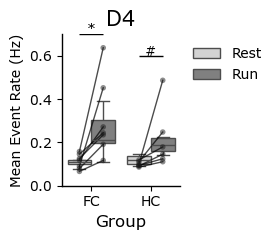

In [23]:
fig,ax=plt.subplots(figsize=(2,2.5))
post = all_df.loc[all_df.Session=='Post']
# sb.barplot(data=post,hue='State',y='Mean Event Rate (Hz)',x='Group',
#            order=['FC','HC'],dodge=True,errorbar='se',ax=ax,palette=['lightgray','gray'],
#            errwidth=1.5,capsize=.1)
sb.boxplot(data=pre,hue='State',y='Mean Event Rate (Hz)',x='Group',showfliers=False,
           order=['FC','HC'],dodge=True,ax=ax,palette=['lightgray','gray'])
sb.stripplot(data=post,hue='State',y='Mean Event Rate (Hz)',order=['FC','HC'],dodge=True,x='Group',palette=['.1','.1'],size=4,jitter=False,alpha=.5,ax=ax,legend=False)
x1,x2,x3,x4 = -.2,.2,.8,1.2
for ani in np.unique(pre['Animal'].values):
    rest = post['Mean Event Rate (Hz)'].loc[(post['Animal']==ani)&(post['State']=='Rest')].values[0]
    run = post['Mean Event Rate (Hz)'].loc[(post['Animal']==ani)&(post['State']=='Run')].values[0]
    if post.Group.loc[post.Animal==ani].values[0]=='HC':
        plt.plot([x3,x4],[rest,run],color='k',alpha=.7,lw=1)
    else:
        plt.plot([x1,x2],[rest,run],color='k',alpha=.7,lw=1)
#ax.get_legend().set_visible(False)
plt.xlabel('Group')
plt.ylabel('Mean Event Rate (Hz)',fontdict={'size':10})
plt.ylim([0,.7])
plt.title('D4')
sb.despine()
plt.tight_layout()
plt.hlines(.7,-.2,.2,color='k',linewidth=1)
plt.text(0,.7,'*',ha='center')
plt.hlines(.6,.8,1.2,color='k',linewidth=1)
plt.text(1,.6,'#',ha='center')
plt.legend(bbox_to_anchor=(1,1),frameon=False)
plt.savefig(f'{path}/rest&run_meanani_allcells_post.svg',transparent=True)

## Supp 4I Stats

In [ ]:
# Rename column to make formula syntax easier
pre = pre.rename(columns={'Mean Event Rate (Hz)': 'EventRate'})
# Convert to categorical if not already
pre['Group'] = pre['Group'].astype('category')
pre['State'] = pre['State'].astype('category')
pre['index'] = pre['index'].astype('category')
# Fit linear mixed-effects model
model = smf.mixedlm("EventRate ~ Group * State", pre, groups=pre["Animal"])
result = model.fit()
# View summary
print(result.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     EventRate
No. Observations:     26          Method:                 REML     
No. Groups:           13          Scale:                  0.0115   
Min. group size:      2           Log-Likelihood:         13.0607  
Max. group size:      2           Converged:              Yes      
Mean group size:      2.0                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.111    0.043  2.595 0.009  0.027  0.195
Group[T.HC]               0.006    0.063  0.102 0.919 -0.117  0.130
State[T.Run]              0.166    0.057  2.889 0.004  0.053  0.278
Group[T.HC]:State[T.Run] -0.047    0.084 -0.560 0.576 -0.213  0.118
Group Var                 0.001    0.039                       

/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [25]:
pg.normality(post,dv='Mean Event Rate (Hz)',group='Group')

,W,pval,normal
Group,,,
FC,0.789604,0.003723,False
HC,0.639013,0.000231,False


In [26]:
pg.mixed_anova(data=post,dv='Mean Event Rate (Hz)',between='Group',within='State',subject='index',)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.017120,1,11,0.017120,1.090279,0.318814,0.090178,NaN
1,State,0.163520,1,11,0.163520,14.279097,0.003054,0.564858,1.0
2,Interaction,0.010177,1,11,0.010177,0.888709,0.366072,0.074752,NaN


In [27]:
pg.pairwise_tests(data=post,dv='Mean Event Rate (Hz)',between='Group',within='State',subject='index',padjust='holm',parametric=False,within_first=False)

,Contrast,Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,29.0,NaN,two-sided,0.294872,NaN,NaN,0.540390
1,State,-,Rest,Run,True,False,NaN,0.0,two-sided,0.000244,NaN,NaN,-1.317933
2,Group * State,FC,Rest,Run,True,False,NaN,0.0,two-sided,0.015625,0.03125,holm,-1.424368
3,Group * State,HC,Rest,Run,True,False,NaN,0.0,two-sided,0.031250,0.03125,holm,-1.063775


In [ ]:
# Rename column to make formula syntax easier
post = post.rename(columns={'Mean Event Rate (Hz)': 'EventRate'})
# Convert to categorical if not already
post['Group'] = post['Group'].astype('category')
post['State'] = post['State'].astype('category')
post['index'] = post['index'].astype('category')
# Fit linear mixed-effects model
model = smf.mixedlm("EventRate ~ Group * State", post, groups=post["Animal"])
result = model.fit()
# View summary
print(result.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     EventRate
No. Observations:     26          Method:                 REML     
No. Groups:           13          Scale:                  0.0115   
Min. group size:      2           Log-Likelihood:         12.4752  
Max. group size:      2           Converged:              Yes      
Mean group size:      2.0                                          
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.112    0.044  2.543 0.011  0.026  0.198
Group[T.HC]              -0.012    0.065 -0.182 0.856 -0.139  0.115
State[T.Run]              0.195    0.057  3.413 0.001  0.083  0.307
Group[T.HC]:State[T.Run] -0.079    0.084 -0.943 0.346 -0.244  0.086
Group Var                 0.002    0.044                       

/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
